In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
 
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import matplotlib
matplotlib.style.use('fivethirtyeight')

import random
random.seed(9001)

# Loading Dataset

In [45]:
main_df = pd.read_csv('insurance_claims.csv')
main_df.head(2)
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

# Handling Missing Values

In [46]:
main_df.isna().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

In [47]:
# missing value:
# authorities_contacted has 91 missing value (1000 - 909)
# fill NA for this features by setting NA = Other

main_df['authorities_contacted'] = main_df['authorities_contacted'].fillna('Other')

In [48]:
# drop _c39 column due to missing value
main_df.drop('_c39', axis = 1, inplace=True)

In [49]:
# print unique value for each columns

for col in main_df.columns:
    print(f"{col}: \n{main_df[col].unique()}\n")


months_as_customer: 
[328 228 134 256 137 165  27 212 235 447  60 121 180 473  70 140 160 196
 460 217 370 413 237   8 257 202 224 241  64 166 155 114 149 147  62 289
 431 199  79 116  37 106 269 265 163 355 175 192 430  91 223 195  22 439
  94  11 151 154 245 119 215 295 254 107 478 128 338 271 222 120 270 319
 194 227 244  78 200 284 275 153  31  41 127  61 207 219  80 325  29 239
 279 350 464 118 298  87 261 453 210 168 390 258 225 164 255 206 203 211
 274  81 280 112  24  93 171 124 287 122 398 214 209  82 193 288 104 101
 375 461 428  45 136 216 278 108  14 276  47  73 294 324  53 426 111  86
 296 125 177 238 449 252 359  19 285  30 342 468 343 404  63 335 142 272
  69  38 281 246 330 362 371 377 172  99 249 190 174  95   2 117 242 440
  20 208 156 232  84 394  35 369 332 243 264  32 259 186 201 436 189 105
  88  40  59  39 123 231 247  48 267 286 253  10 158   1  85 233 266  97
 399 305 129 283  96 176 159 290 299  66 334 429  15 230 250  65 475  77
 229 110 292 451 150 291 162 3

In [50]:
main_df.groupby(['collision_type']).agg({'policy_number':'count'}).reset_index()

,collision_type,policy_number
0,?,178
1,Front Collision,254
2,Rear Collision,292
3,Side Collision,276


In [51]:
main_df.groupby(['property_damage']).agg({'policy_number':'count'}).reset_index()

,property_damage,policy_number
0,?,360
1,NO,338
2,YES,302


In [52]:
main_df.groupby(['police_report_available']).agg({'policy_number':'count'}).reset_index()

,police_report_available,policy_number
0,?,343
1,NO,343
2,YES,314


In [ ]:
# replace '?' the the most frequent categorical variable at the same columns
main_df.replace({'collision_type': {'?': 'Rear Collision'}, 'property_damage': {'?': 'NO'}, 'police_report_available': {'?': 'NO'}}, inplace=True)

In [54]:
main_df.shape

(1000, 39)

In [55]:
# Change datatype
# policy_bind_date should be date type
# incident_date should be date type
main_df[["policy_bind_date", "incident_date"]] = main_df[["policy_bind_date", "incident_date"]].apply(pd.to_datetime)

main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          1000 non-null   int64         
 2   policy_number                1000 non-null   int64         
 3   policy_bind_date             1000 non-null   datetime64[ns]
 4   policy_state                 1000 non-null   object        
 5   policy_csl                   1000 non-null   object        
 6   policy_deductable            1000 non-null   int64         
 7   policy_annual_premium        1000 non-null   float64       
 8   umbrella_limit               1000 non-null   int64         
 9   insured_zip                  1000 non-null   int64         
 10  insured_sex                  1000 non-null   object        
 11  insured_education_level      1000 non-null  

# EDA

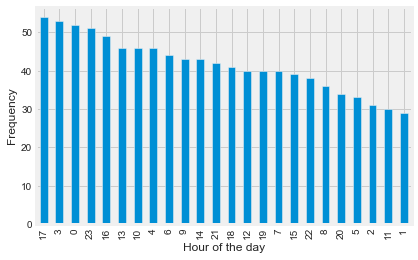

In [58]:
# Bar plot number of incidence per hour
fig, ax = plt.subplots()
#plt.figure(figsize = (18, 12))

main_df['incident_hour_of_the_day'].value_counts().plot(ax=ax, kind='bar', xlabel='Hour of the day', ylabel='Frequency')
plt.show()
# incidences mostly happens at 17.00

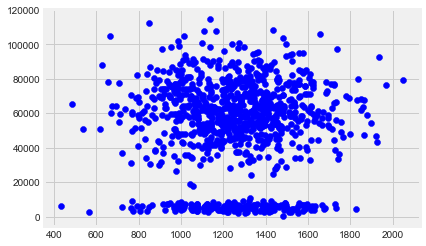

In [59]:
# scatter plot of annual premium vs total claim amount
plt.scatter(x = main_df['policy_annual_premium'], y = main_df['total_claim_amount'], c = 'blue')
plt.show()

Text(0.5, 0, 'Count')

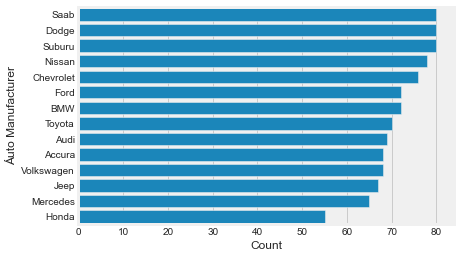

In [60]:
sns.countplot(y='auto_make',data=main_df, order = main_df['auto_make'].value_counts().index)
plt.ylabel('Áuto Manufacturer')
plt.xlabel('Count')

In [62]:
# by auto_make
fraud_by_automake = main_df.groupby(['auto_make', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_automake.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# Audi, Mercedes, ford : fraud >30%

fraud_reported
auto_make  auto_make  fraud_reported                
Accura     Accura     N                         81.0
                      Y                         19.0
Audi       Audi       N                         70.0
                      Y                         30.0
BMW        BMW        N                         72.0
                      Y                         28.0
Chevrolet  Chevrolet  N                         72.0
                      Y                         28.0
Dodge      Dodge      N                         75.0
                      Y                         25.0
Ford       Ford       N                         69.0
                      Y                         31.0
Honda      Honda      N                         75.0
                      Y                         25.0
Jeep       Jeep       N                         84.0
                      Y                         16.0
Mercedes   Mercedes   N                         66.0
                      Y                         34.0
Nissan     Nissan     N                         82.0
                      Y                         18.0
Saab       Saab       N                         78.0
                      Y                         22.0
Suburu     Suburu     N                         76.0
                      Y                         24.0
Toyota     Toyota     N                         81.0
                      Y                         19.0
Volkswagen Volkswagen N                         72.0
                      Y                         28.0

<Axes: xlabel='count', ylabel='auto_make'>

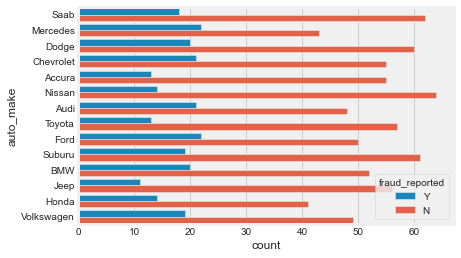

In [63]:
sns.countplot(y='auto_make',hue='fraud_reported',data=main_df)


fraud_reported
policy_csl policy_csl fraud_reported                
100/300    100/300    N                         74.0
                      Y                         26.0
250/500    250/500    N                         74.0
                      Y                         26.0
500/1000   500/1000   N                         78.0
                      Y                         22.0

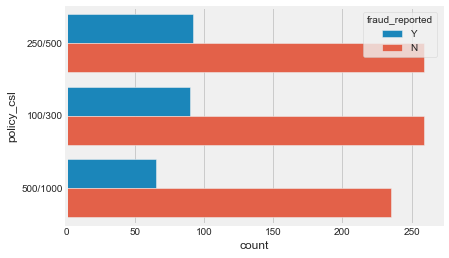

In [64]:
sns.countplot(y='policy_csl',hue='fraud_reported',data=main_df)

# policy_csl 
fraud_by_policy_csl = main_df.groupby(['policy_csl', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_policy_csl.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# csl 100/300 and 250/500 : fraud =26%

fraud_reported
insured_sex insured_sex fraud_reported                
FEMALE      FEMALE      N                         77.0
                        Y                         23.0
MALE        MALE        N                         74.0
                        Y                         26.0

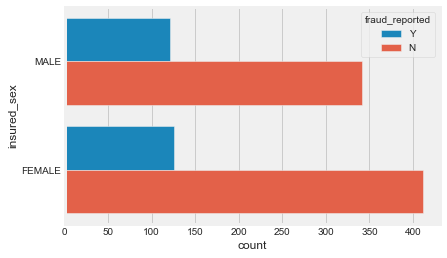

In [65]:
sns.countplot(y='insured_sex',hue='fraud_reported',data=main_df)

# insured_sex 
fraud_by_insured_sex = main_df.groupby(['insured_sex', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_insured_sex.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# male (26%) sligtly higher than female (24%) for making fraud

fraud_reported
insured_education_level insured_education_level fraud_reported                
Associate               Associate               N                         77.0
                                                Y                         23.0
College                 College                 N                         74.0
                                                Y                         26.0
High School             High School             N                         78.0
                                                Y                         22.0
JD                      JD                      N                         74.0
                                                Y                         26.0
MD                      MD                      N                         74.0
                                                Y                         26.0
Masters                 Masters                 N                         78.0
                                                Y                         22.0
PhD                     PhD                     N                         74.0
                                                Y                         26.0

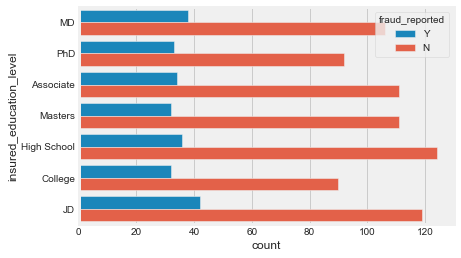

In [66]:
sns.countplot(y='insured_education_level',hue='fraud_reported',data=main_df)

# insured_education_level 
fraud_by_insured_education_level = main_df.groupby(['insured_education_level', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_insured_education_level.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# College, JD, MD, PhD fraud = 26% 

fraud_reported
incident_severity incident_severity fraud_reported                
Major Damage      Major Damage      N                         39.0
                                    Y                         61.0
Minor Damage      Minor Damage      N                         89.0
                                    Y                         11.0
Total Loss        Total Loss        N                         87.0
                                    Y                         13.0
Trivial Damage    Trivial Damage    N                         93.0
                                    Y                          7.0

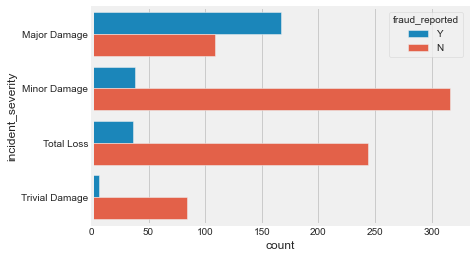

In [67]:
sns.countplot(y='incident_severity',hue='fraud_reported',data=main_df)

# incident_severity 
fraud_by_incident_severity = main_df.groupby(['incident_severity', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_incident_severity.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# Major damage 61%

fraud_reported
incident_type            incident_type            fraud_reported                
Multi-vehicle Collision  Multi-vehicle Collision  N                         73.0
                                                  Y                         27.0
Parked Car               Parked Car               N                         90.0
                                                  Y                         10.0
Single Vehicle Collision Single Vehicle Collision N                         71.0
                                                  Y                         29.0
Vehicle Theft            Vehicle Theft            N                         91.0
                                                  Y                          9.0

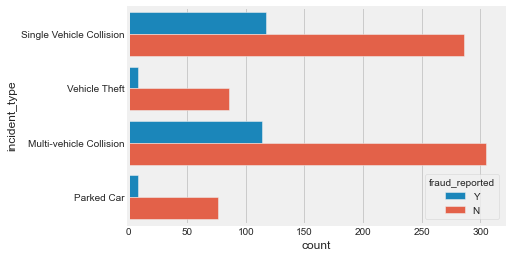

In [68]:
sns.countplot(y='incident_type',hue='fraud_reported',data=main_df)

# incident_type 
fraud_by_incident_type = main_df.groupby(['incident_type', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_incident_type.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# Single Vehicle Collision 29%

fraud_reported
insured_hobbies insured_hobbies fraud_reported                
base-jumping    base-jumping    N                         73.0
                                Y                         27.0
basketball      basketball      N                         82.0
                                Y                         18.0
board-games     board-games     N                         71.0
                                Y                         29.0
bungie-jumping  bungie-jumping  N                         84.0
                                Y                         16.0
camping         camping         N                         91.0
                                Y                          9.0
chess           chess           N                         17.0
                                Y                         83.0
cross-fit       cross-fit       N                         26.0
                                Y                         74.0
dancing         dancing         N                         88.0
                                Y                         12.0
exercise        exercise        N                         81.0
                                Y                         19.0
golf            golf            N                         89.0
                                Y                         11.0
hiking          hiking          N                         77.0
                                Y                         23.0
kayaking        kayaking        N                         91.0
                                Y                          9.0
movies          movies          N                         84.0
                                Y                         16.0
paintball       paintball       N                         77.0
                                Y                         23.0
polo            polo            N                         72.0
                                Y                         28.0
reading         reading         N                         73.0
                                Y                         27.0
skydiving       skydiving       N                         78.0
                                Y                         22.0
sleeping        sleeping        N                         80.0
                                Y                         20.0
video-games     video-games     N                         80.0
                                Y                         20.0
yachting        yachting        N                         70.0
                                Y                         30.0

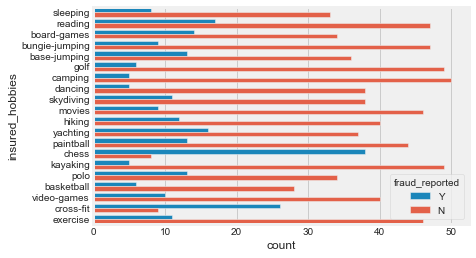

In [69]:
sns.countplot(y='insured_hobbies',hue='fraud_reported',data=main_df)

# insured_hobbies 
fraud_by_insured_hobbies = main_df.groupby(['insured_hobbies', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_insured_hobbies.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# Chess 83%, cross-fit 71%

fraud_reported
insured_occupation insured_occupation fraud_reported                
adm-clerical       adm-clerical       N                         83.0
                                      Y                         17.0
armed-forces       armed-forces       N                         75.0
                                      Y                         25.0
craft-repair       craft-repair       N                         70.0
                                      Y                         30.0
exec-managerial    exec-managerial    N                         63.0
                                      Y                         37.0
farming-fishing    farming-fishing    N                         70.0
                                      Y                         30.0
handlers-cleaners  handlers-cleaners  N                         80.0
                                      Y                         20.0
machine-op-inspct  machine-op-inspct  N                         76.0
                                      Y                         24.0
other-service      other-service      N                         83.0
                                      Y                         17.0
priv-house-serv    priv-house-serv    N                         83.0
                                      Y                         17.0
prof-specialty     prof-specialty     N                         79.0
                                      Y                         21.0
protective-serv    protective-serv    N                         78.0
                                      Y                         22.0
sales              sales              N                         72.0
                                      Y                         28.0
tech-support       tech-support       N                         72.0
                                      Y                         28.0
transport-moving   transport-moving   N                         71.0
                                      Y                         29.0

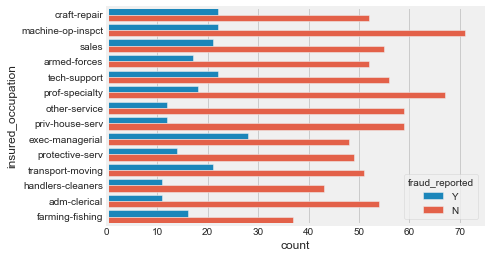

In [70]:
sns.countplot(y='insured_occupation',hue='fraud_reported',data=main_df)

# insured_hobbies 
fraud_by_insured_occupation = main_df.groupby(['insured_occupation', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_insured_occupation.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# exec-managerial 37%

In [71]:
# extracting the numerical columns

num_df = main_df.select_dtypes(include = ['int64', 'float64'])

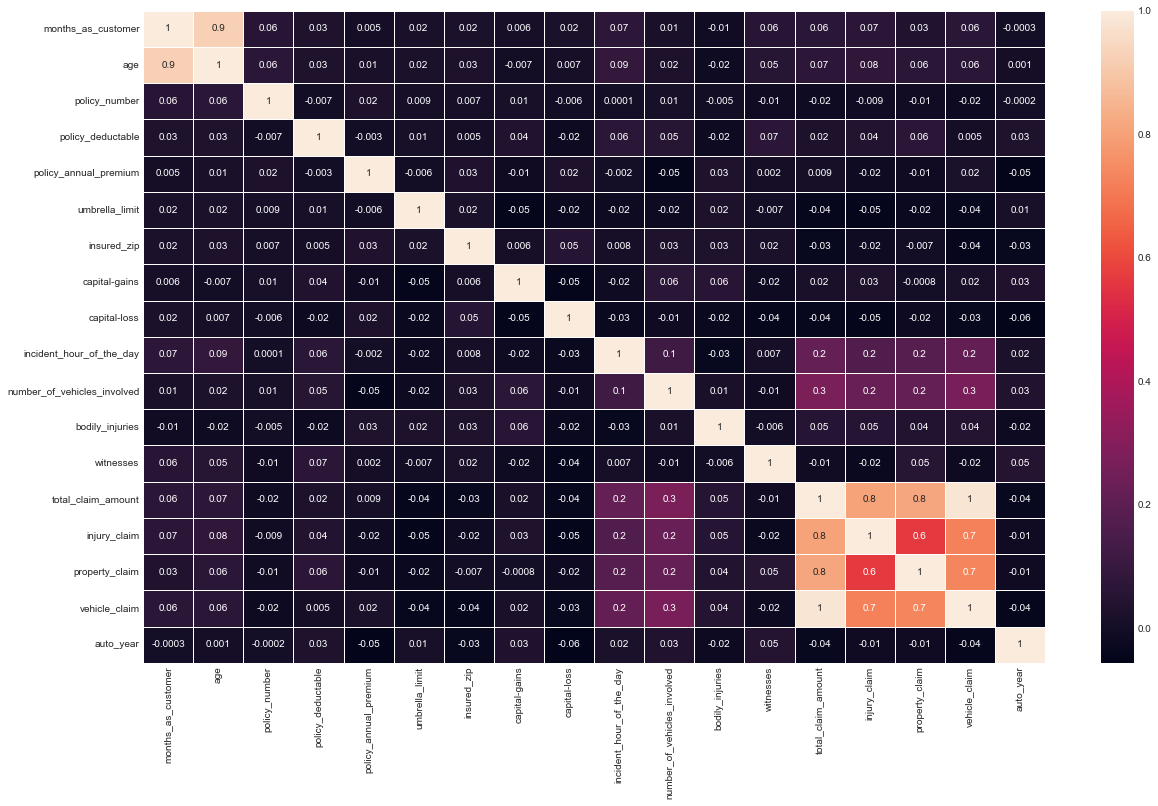

In [72]:
# Heatmap correlation plot for all variables

plt.figure(figsize = (18, 12))

corr = num_df.corr()
#mask = np.triu(np.ones_like(corr, dtype = bool))
# mask = mask,
sns.heatmap(data = corr,  annot = True, fmt = '.1g', linewidth = 1)
plt.show()

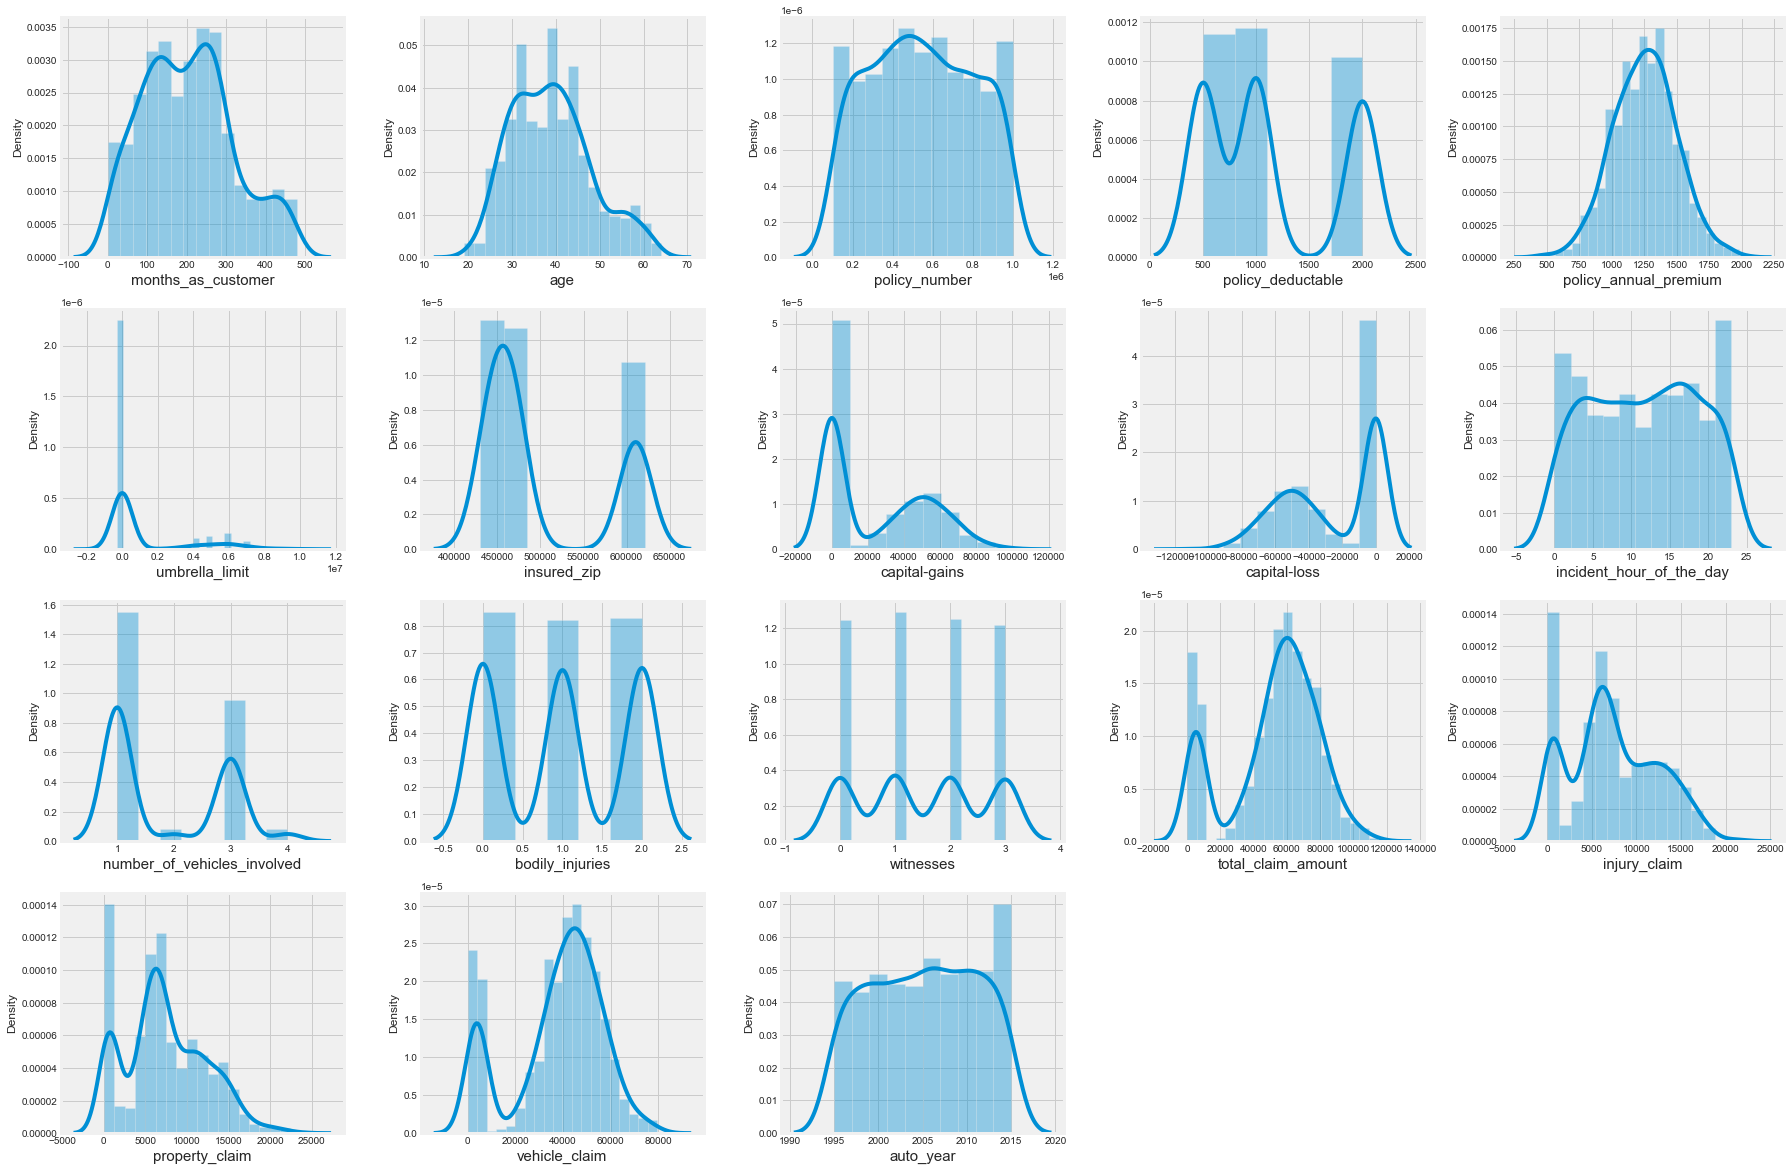

In [73]:
# Histogram of Continuous variable
plt.figure(figsize = (25, 20))
plotnumber = 1

for col in num_df.columns:
    if plotnumber <= 24:
        ax = plt.subplot(5, 5, plotnumber)
        sns.distplot(num_df[col])
        plt.xlabel(col, fontsize = 15)
        
    plotnumber += 1
    
plt.tight_layout()
plt.show()

In [ ]:
# split numerical and categorical variable

In [76]:
# extracting categorical columns

cat_df = main_df.select_dtypes(include = ['object'])

for col in cat_df.columns:
    print(f"{col}: \n{cat_df[col].unique()}\n")
    
to_drop_cat = ['incident_location','incident_state','incident_city']
# remove 'incident_location','incident_state','incident_city'
cat_df.drop(to_drop_cat, inplace = True, axis = 1)

policy_state: 
['OH' 'IN' 'IL']

policy_csl: 
['250/500' '100/300' '500/1000']

insured_sex: 
['MALE' 'FEMALE']

insured_education_level: 
['MD' 'PhD' 'Associate' 'Masters' 'High School' 'College' 'JD']

insured_occupation: 
['craft-repair' 'machine-op-inspct' 'sales' 'armed-forces' 'tech-support'
 'prof-specialty' 'other-service' 'priv-house-serv' 'exec-managerial'
 'protective-serv' 'transport-moving' 'handlers-cleaners' 'adm-clerical'
 'farming-fishing']

insured_hobbies: 
['sleeping' 'reading' 'board-games' 'bungie-jumping' 'base-jumping' 'golf'
 'camping' 'dancing' 'skydiving' 'movies' 'hiking' 'yachting' 'paintball'
 'chess' 'kayaking' 'polo' 'basketball' 'video-games' 'cross-fit'
 'exercise']

insured_relationship: 
['husband' 'other-relative' 'own-child' 'unmarried' 'wife' 'not-in-family']

incident_type: 
['Single Vehicle Collision' 'Vehicle Theft' 'Multi-vehicle Collision'
 'Parked Car']

collision_type: 
['Side Collision' 'Rear Collision' 'Front Collision']

incident_severit

In [ ]:
df.churn = (df.churn == 'yes').astype(int)

In [77]:
# separating the feature and target columns

# outcome
y = cat_df['fraud_reported']

# features
cat_df.drop('fraud_reported', inplace = True ,axis = 1)

In [78]:
# categorical variable to dummies

cat_df = pd.get_dummies(cat_df, drop_first = True)

In [79]:
# combining the Numerical and Categorical dataframes to get the final dataset

X = pd.concat([num_df, cat_df], axis = 1)

# Modeling

In [81]:
# splitting data into training set and test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [82]:
# Support Vector Classifier (SVC)
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)

# accuracy_score

svc_train_acc = accuracy_score(y_train, svc.predict(X_train))
svc_test_acc = accuracy_score(y_test, y_pred)

print(f"Training accuracy of Support Vector Classifier is : {svc_train_acc}")
print(f"Test accuracy of Support Vector Classifier is : {svc_test_acc}")

Training accuracy of Support Vector Classifier is : 0.7475
Test accuracy of Support Vector Classifier is : 0.775


In [83]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 30)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# accuracy_score

knn_train_acc = accuracy_score(y_train, knn.predict(X_train))
knn_test_acc = accuracy_score(y_test, y_pred)

print(f"Training accuracy of KNN is : {knn_train_acc}")
print(f"Test accuracy of KNN is : {knn_test_acc}")

Training accuracy of KNN is : 0.74625
Test accuracy of KNN is : 0.775


In [84]:
# Decision tree classifier
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

y_pred = dtc.predict(X_test)

dtc_train_acc = accuracy_score(y_train, dtc.predict(X_train))
dtc_test_acc = accuracy_score(y_test, y_pred)

print(f"Training accuracy of Decision Tree is : {dtc_train_acc}")
print(f"Test accuracy of Decision Tree is : {dtc_test_acc}")

# hyper parameter tuning

from sklearn.model_selection import GridSearchCV

grid_params = {
    'criterion' : ['gini', 'entropy'],
    'max_depth' : [3, 5, 7, 10],
    'min_samples_split' : range(2, 10, 1),
    'min_samples_leaf' : range(2, 10, 1)
}

grid_search = GridSearchCV(dtc, grid_params, cv = 10, n_jobs = -1, verbose = 1)
grid_search.fit(X_train, y_train)

# best parameters and best score

print(grid_search.best_params_)
print(grid_search.best_score_)

# best estimator 

dtc = grid_search.best_estimator_

y_pred = dtc.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dtc_train_acc = accuracy_score(y_train, dtc.predict(X_train))
dtc_test_acc = accuracy_score(y_test, y_pred)

print(f"Training accuracy of Decision Tree is : {dtc_train_acc}")
print(f"Test accuracy of Decision Tree is : {dtc_test_acc}")

Training accuracy of Decision Tree is : 1.0
Test accuracy of Decision Tree is : 0.79
Fitting 10 folds for each of 512 candidates, totalling 5120 fits
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 5}
0.8612500000000001
Training accuracy of Decision Tree is : 0.8725
Test accuracy of Decision Tree is : 0.84


In [85]:
# Random forest classifier

from sklearn.ensemble import RandomForestClassifier

rand_clf = RandomForestClassifier(criterion= 'entropy', max_depth= 10, max_features= 'sqrt', min_samples_leaf= 1, min_samples_split= 3, n_estimators= 140)
rand_clf.fit(X_train, y_train)

y_pred = rand_clf.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rand_clf_train_acc = accuracy_score(y_train, rand_clf.predict(X_train))
rand_clf_test_acc = accuracy_score(y_test, y_pred)

print(f"Training accuracy of Random Forest is : {rand_clf_train_acc}")
print(f"Test accuracy of Random Forest is : {rand_clf_test_acc}")

Training accuracy of Random Forest is : 0.9625
Test accuracy of Random Forest is : 0.785


In [86]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of gradient boosting classifier

gb_acc = accuracy_score(y_test, gb.predict(X_test))

print(f"Training Accuracy of Gradient Boosting Classifier is {accuracy_score(y_train, gb.predict(X_train))}")
print(f"Test Accuracy of Gradient Boosting Classifier is {gb_acc} \n")

Training Accuracy of Gradient Boosting Classifier is 0.96375
Test Accuracy of Gradient Boosting Classifier is 0.845 



In [87]:
# Stocastic Gradient boosting

sgb = GradientBoostingClassifier(subsample = 0.90, max_features = 0.70)
sgb.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of stochastic gradient boosting classifier

sgb_acc = accuracy_score(y_test, sgb.predict(X_test))

print(f"Training Accuracy of Stochastic Gradient Boosting is {accuracy_score(y_train, sgb.predict(X_train))}")
print(f"Test Accuracy of Stochastic Gradient Boosting is {sgb_acc} \n")

Training Accuracy of Stochastic Gradient Boosting is 0.965
Test Accuracy of Stochastic Gradient Boosting is 0.84 



In [88]:
# Model Comparison

models = pd.DataFrame({
    'Model' : ['SVC', 'KNN', 'Decision Tree', 'Random Forest', 'Gradient Boost', 'SGB' ], # ,'XgBoost' , ,'Ada Boost'
    'Score' : [svc_test_acc, knn_test_acc, dtc_test_acc, rand_clf_test_acc, gb_acc, sgb_acc] #, xgb_test_acc, ada_test_acc,
})


models.sort_values(by = 'Score', ascending = False)

,Model,Score
4,Gradient Boost,0.845
2,Decision Tree,0.840
5,SGB,0.840
3,Random Forest,0.785
0,SVC,0.775
1,KNN,0.775
